# PHASE 2
## Project Medical Cost
##### tala

## Import Libraries

In [155]:
import pandas as pd # work with data
import numpy as np # use calculatons
import seaborn as sns # use to draw graphs
import matplotlib.pyplot as plt # use ploting graphs

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## laod the cleaned file

In [156]:
df = pd.read_csv('/content/cleaned_insurance.csv') #read the database

## Verify the file is loaded correctly

In [157]:
print("\033[94m________________________First 5 rows________________________\033[0m :\n") #show first 5 rows to make sure data read correctly
df.head()


________________________First 5 rows________________________ :



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## One-hot encode

In [158]:
one_hot = pd.get_dummies(df,columns = ["sex","region"])
print("\033[94m-----------------------------------------------------First 5 rows one hot------------------------------------------------------------------\033[0m")
one_hot.head()
#help model read categories

-----------------------------------------------------First 5 rows one hot------------------------------------------------------------------


,age,bmi,children,smoker,charges,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,yes,16884.92400,True,False,False,False,False,True
1,18,33.770,1,no,1725.55230,False,True,False,False,True,False
2,28,33.000,3,no,4449.46200,False,True,False,False,True,False
3,33,22.705,0,no,21984.47061,False,True,False,True,False,False
4,32,28.880,0,no,3866.85520,False,True,False,True,False,False


## Ordinal encode

In [159]:
# we cannot use ordinal encoding because we do not have any column ready for use

## Scale

In [160]:
# split feature & target
x = one_hot.drop("charges",axis = 1) # feature
y = one_hot["charges"] # target

In [161]:
x_train , x_test , y_train , y_test = train_test_split (
    x , y , test_size = 0.2 , random_state = 42)
# split data into training and testing
# trainig is ues to train the model
# testing is uesd to check model is trining well

In [162]:
scaling = ["age","bmi"]
# Scaling helps to put numerical features in the same range for better model

In [163]:
SS = StandardScaler()
x_train[scaling] = SS.fit_transform(x_train[scaling])
x_test[scaling] = SS.transform(x_test[scaling])
# makes age & bmi have mean  = 0 & std = 1 for better model training

## Create 2 domain features

In [164]:
df["bmi&child"] = df["bmi"]/df["children"].replace(0,np.nan)
df["bmi&child"] = df["bmi&child"].fillna(0)
# create new feature bmi & child

In [165]:
df["fat"] = (df["bmi"] >= 30).astype(int)
# create new feature fat
# i used >= 30 becouse it is global obesity standard

## Create 1 interaction feature

In [166]:
df["elderly"] = df["age"] * df["bmi"]
# age & bmi they explain the amount of danger

## Log-transform

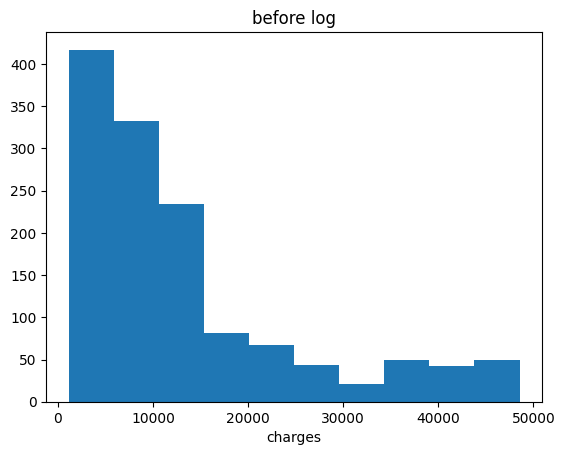

In [167]:
plt.hist(df["charges"])
plt.title("before log")
plt.xlabel("charges")
plt.show()
# Check charges distribution

In [168]:
df["ChargesLog"] = np.log1p(df["charges"])
# Apply log transform to charges
# Makes skewed data more normal for modeling

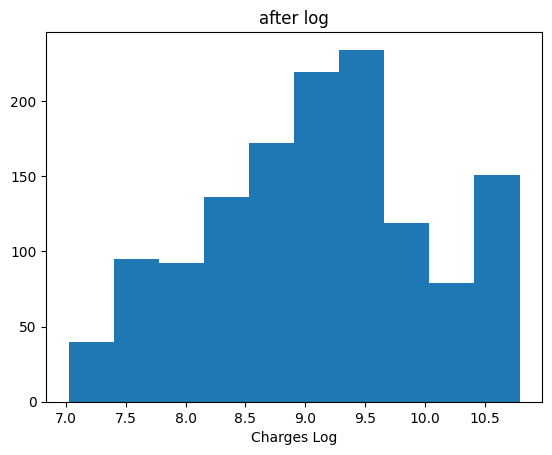

In [169]:
plt.hist(df["ChargesLog"])
plt.title("after log")
plt.xlabel("Charges Log")
plt.show()
# Check charges distribution after log

## Bin

In [170]:
bins = [0,18,35,55,100]
labels = ["child" , "Young Adult" , "Adult" , "Senior"]
df["age_group"] = pd.cut(df["age"] , bins = bins , labels = labels)
# create age groups
# group age into child, young adult, adult, senior

## Remove redundant features

In [171]:
corr = df.corr(numeric_only = True).abs() # get corr & take absolute value
upper = corr.where(np.triu(np.ones(corr.shape) , k = 1).astype(bool)) # upper triangle
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)] # find cols to drop
df = df.drop(columns = to_drop),to_drop # drop them & show dropped col
# Remove very corr columns